## Install librearies

In [1]:
!pip install -qU azure-ai-inference

## Import libraries and set up the client

In [38]:
import os
from azure.ai.inference import ChatCompletionsClient
from azure.core.credentials import AzureKeyCredential
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("AZURE_INFERENCE_CREDENTIAL", '')
if not api_key:
    raise Exception("A key should be provided to invoke the endpoint")

client = ChatCompletionsClient(
    endpoint='https://Phi-4-multimodal-instruct-jrwry.eastus2.models.ai.azure.com',
    credential=AzureKeyCredential(api_key)
)

model_info = client.get_model_info()
print("Model name:", model_info.model_name)
print("Model type:", model_info.model_type)
print("Model provider name:", model_info.model_provider_name)


Model name: Phi-4-multilmodal-instruct
Model type: chat-completion
Model provider name: Phi


## Generate a completion on text

In [39]:
from azure.ai.inference.models import SystemMessage, UserMessage

response = client.complete(
    messages=[
        SystemMessage(content="Eres un experto en post de linkedin y redes sociales"),
        UserMessage(content="Dame un post hablanso sobre el impacto de AI en la educacion"),
    ],
)

print("Response:", response.choices[0].message.content)
print("Model:", response.model)
print("Usage:")
print("	Prompt tokens:", response.usage.prompt_tokens)
print("	Total tokens:", response.usage.total_tokens)
print("	Completion tokens:", response.usage.completion_tokens)

Response: ¡Imagina una educación donde el aprendizaje personalizado es la norma, los maestros centran su atención en ayudar a los estudiantes a superar obstáculos, y la investigación abre puertas para código sin fin! La Inteligencia Artificial está revolucionando la educación, ofreciendo experiencias de aprendizaje más inmersivas, accesibles y eficazes. ¡Es un cambio para la era futura! 🌟

#InteligenciaArtificial #Educación #AprendizajePersonalizado #TecnologíaEnLaEducación #FuturoDeLaEduca
Model: Phi-4-multilmodal-instruct
Usage:
	Prompt tokens: 31
	Total tokens: 137
	Completion tokens: 106


## Generate a completion on an image

In [51]:
from urllib.request import urlopen, Request
import base64

image_url = "https://azure.microsoft.com/en-us/blog/wp-content/uploads/2025/02/F2.webp"
image_format = "webp"

request = Request(image_url, headers={"User-Agent": "Mozilla/5.0"})
image_data = base64.b64encode(urlopen(request).read()).decode("utf-8")
data_url = f"data:image/{image_format};base64,{image_data}"

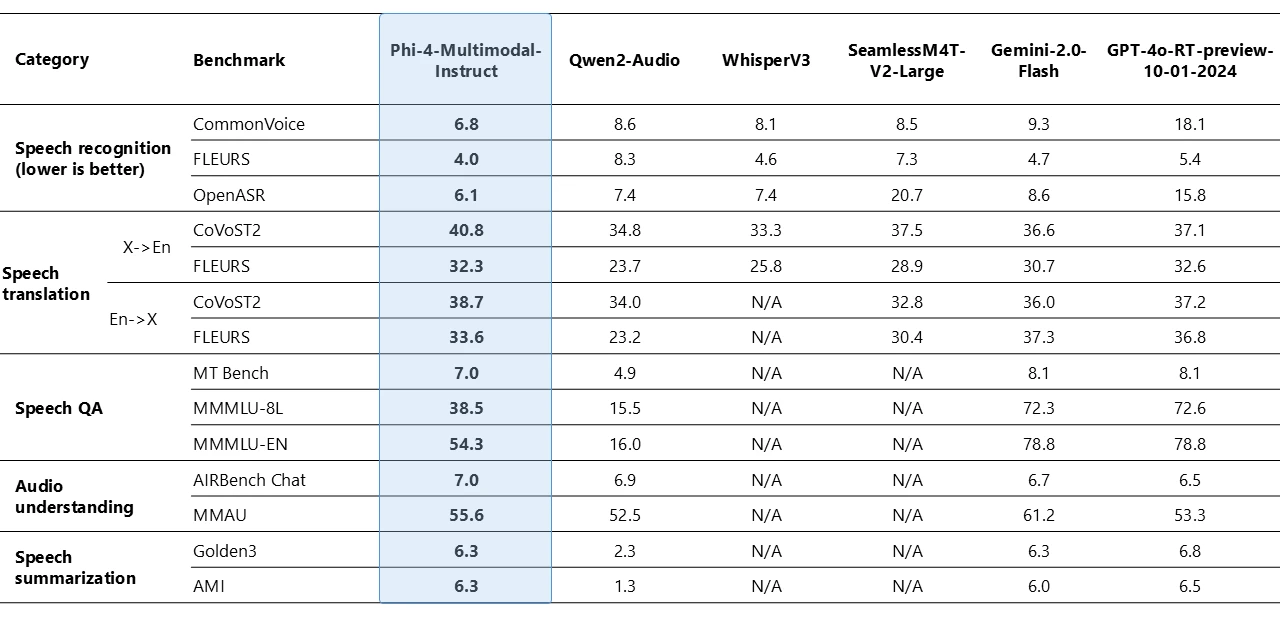

In [52]:
import requests
import IPython.display as Disp

Disp.Image(requests.get(image_url).content)

In [46]:
from azure.ai.inference.models import TextContentItem, ImageContentItem, ImageUrl
response = client.complete(
    messages=[
        SystemMessage("You are a helpful assistant that can generate responses based on images."),
        UserMessage(content=[
            TextContentItem(text="Which conclusion can be extracted from the following chart?"),
            ImageContentItem(image_url=ImageUrl(url=data_url))
        ]),
    ],
    temperature=0,
    top_p=1,
    max_tokens=2048,
)

In [47]:
print("Response:", response.choices[0].message.content)
print("Model:", response.model)
print("Usage:")
print("	Prompt tokens:", response.usage.prompt_tokens)
print("	Total tokens:", response.usage.total_tokens)
print("	Completion tokens:", response.usage.completion_tokens)

Response: The chart compares the performance of different AI models across various benchmarks and categories. The models are evaluated based on their accuracy, and the results are presented in a tabular format. The categories include popular aggregated benchmark, visual scientific knowledge reasoning, visual math reasoning, chart & table reasoning, document intelligence, object visual presence, and multi-image perception. The benchmarks include MMMU, MMBench, MMMU-Pro, ScienceQA, MathVista, InterGPS, ChartQA, DocVQA, InfoVQA, TextVQA, OCR Bench, POPE, BLINK, and Video MME. The models are evaluated on different tasks, such as Phi-4-Multimodal-Instruct, Phi-3.5-Visual-Instruct, Qwen 2.5-VL-3B-Instruct, Intern VL 2.5-4B, Qwen 2.5-VL-7B-Instruct, Intern VL 2.5-8B, Gemini-2.0-Flash-Lite-preview-0205, Gemini-2.0-Flash, Claude-3.5-Somnet-2024-10-22, and GPT-4o-2024-11-20. The results show that the performance of the models varies across different tasks and categories, with some models perform